In [1]:
import subprocess, sys, importlib

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--upgrade",
    "reasoning-from-scratch", "tokenizers", "datasets", "tqdm", "sympy",
])
importlib.invalidate_caches()

import reasoning_from_scratch
print("reasoning_from_scratch version:", reasoning_from_scratch.__version__)

reasoning_from_scratch version: 0.1.21


In [2]:
from pathlib import Path
import torch
from reasoning_from_scratch.qwen3 import (
    download_qwen3_small, Qwen3Tokenizer, Qwen3Model, QWEN_CONFIG_06_B, KVCache,
)
from reasoning_from_scratch.ch02 import get_device

In [3]:
def load_model_and_tokenizer(which_model, device, use_compile, local_dir="."):
    if which_model == "base":
        download_qwen3_small(kind="base", tokenizer_only=False, out_dir=local_dir)
        tokenizer_path = Path(local_dir) / "tokenizer-base.json"
        model_path     = Path(local_dir) / "qwen3-0.6B-base.pth"
        tokenizer = Qwen3Tokenizer(tokenizer_file_path=str(tokenizer_path))

    elif which_model == "reasoning":
        download_qwen3_small(kind="reasoning", tokenizer_only=False, out_dir=local_dir)
        tokenizer_path = Path(local_dir) / "tokenizer-reasoning.json"
        model_path     = Path(local_dir) / "qwen3-0.6B-reasoning.pth"
        tokenizer = Qwen3Tokenizer(
            tokenizer_file_path=str(tokenizer_path),
            apply_chat_template=True,
            add_generation_prompt=True,
            add_thinking=True,
        )

    else:
        raise ValueError(f"Invalid choice: which_model={which_model!r}")

    model = Qwen3Model(QWEN_CONFIG_06_B)
    model.load_state_dict(torch.load(model_path, map_location="cpu", weights_only=True))
    model.to(device)

    if use_compile:
        torch._dynamo.config.allow_unspec_int_on_nn_module = True
        model = torch.compile(model)

    return model, tokenizer

In [4]:
WHICH_MODEL = "base"   # "base" or "reasoning"

device = get_device()
model, tokenizer = load_model_and_tokenizer(
    which_model=WHICH_MODEL,
    device=device,
    use_compile=True,
)

Using NVIDIA CUDA GPU
qwen3-0.6B-base.pth: 100% (1433 MiB / 1433 MiB)


In [5]:
@torch.inference_mode()
def generate_text_basic_stream_cache(model, token_ids, max_new_tokens, eos_token_id=None):
    """Autoregressive generation with KV cache, yielding one token tensor at a time."""
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    out = model(token_ids, cache=cache)[:, -1]

    for _ in range(max_new_tokens):
        next_token = torch.argmax(out, dim=-1, keepdim=True)

        if eos_token_id is not None and torch.all(next_token == eos_token_id):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [6]:
prompt = (
    r"If $a+b=3$ and $ab=\tfrac{13}{6}$, "
    r"what is the value of $a^2+b^2$?"
)

input_token_ids_tensor = torch.tensor(
    tokenizer.encode(prompt),
    device=device
).unsqueeze(0)

all_token_ids = []
for token in generate_text_basic_stream_cache(
    model=model,
    token_ids=input_token_ids_tensor,
    max_new_tokens=2048,
    eos_token_id=tokenizer.eos_token_id,
):
    token_id = token.squeeze(0)
    print(tokenizer.decode(token_id.tolist()), end="", flush=True)
    all_token_ids.append(token_id)

all_tokens = tokenizer.decode([t.item() for t in all_token_ids])

W0713 16:49:24.895000 605 torch/_inductor/utils.py:1731] [0/0] Not enough SMs to use max_autotune_gemm mode
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


 To

/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:2941: UserWarning: Tesla T4 does not support bfloat16 compilation natively, skipping
  warnings.warn(


 find the value of \( a^2 + b^2 \) given that \( a + b = 3 \) and \( ab = \frac{13}{6} \), we can use the following algebraic identity:

\[
a^2 + b^2 = (a + b)^2 - 2ab
\]

**Step 1:** Substitute the given values into the equation.

\[
a^2 + b^2 = (3)^2 - 2 \left( \frac{13}{6} \right)
\]

**Step 2:** Calculate \( (3)^2 \).

\[
(3)^2 = 9
\]

**Step 3:** Calculate \( 2 \times \frac{13}{6} \).

\[
2 \times \frac{13}{6} = \frac{26}{6} = \frac{13}{3}
\]

**Step 4:** Subtract the second result from the first.

\[
a^2 + b^2 = 9 - \frac{13}{3}
\]

**Step 5:** Convert 9 to a fraction with a denominator of 3 to perform the subtraction.

\[
9 = \frac{27}{3}
\]

\[
a^2 + b^2 = \frac{27}{3} - \frac{13}{3} = \frac{14}{3}
\]

**Final Answer:**

\[
\boxed{\dfrac{14}{3}}
\]

In [7]:
def get_last_boxed(text):
    boxed_start_idx = text.rfind(r"\boxed")
    if boxed_start_idx == -1:
        return None

    current_idx = boxed_start_idx + len(r"\boxed")

    while current_idx < len(text) and text[current_idx].isspace():
        current_idx += 1

    if current_idx >= len(text) or text[current_idx] != "{":
        return None

    current_idx += 1
    brace_depth = 1
    content_start_idx = current_idx

    while current_idx < len(text) and brace_depth > 0:
        char = text[current_idx]
        if char == "{":
            brace_depth += 1
        elif char == "}":
            brace_depth -= 1
        current_idx += 1

    if brace_depth != 0:
        return None

    return text[content_start_idx:current_idx - 1]

In [8]:
extracted_answer = get_last_boxed(all_tokens)
print(extracted_answer)

\dfrac{14}{3}


In [9]:
from IPython.display import Math
display(Math(extracted_answer))

<IPython.core.display.Math object>

In [10]:
def generate_text_stream_concat(model, tokenizer, prompt, device, max_new_tokens, verbose=False):
    input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)
    generated_ids = []
    for token in generate_text_basic_stream_cache(model, input_ids, max_new_tokens,
                                                   eos_token_id=tokenizer.eos_token_id):
        token_id = token.squeeze(0)
        generated_ids.append(token_id.item())
        if verbose:
            print(tokenizer.decode(token_id.tolist()), end="", flush=True)
    return tokenizer.decode(generated_ids)

In [11]:
import re

LATEX_FIXES = [
    (r"\\left\s*",       ""),
    (r"\\right\s*",      ""),
    (r"\\,|\\!|\\;|\\:", ""),
    (r"\\cdot",          "*"),
    (r"·|×",   "*"),
    (r"\\\^\\circ",      ""),
    (r"\\dfrac",         r"\\frac"),
    (r"\\tfrac",         r"\\frac"),
    (r"°",               ""),
]

RE_SPECIAL = re.compile(r"<\|[^>]+?\|>")

SUPERSCRIPT_MAP = {
    "⁰": "0", "¹": "1", "²": "2", "³": "3", "⁴": "4",
    "⁵": "5", "⁶": "6", "⁷": "7", "⁸": "8", "⁹": "9",
    "⁺": "+", "⁻": "-", "⁽": "(", "⁾": ")",
}


def normalize_text(text):
    if not text:
        return ""

    text = RE_SPECIAL.sub("", text).strip()

    # Strip leading multiple-choice labels like "c. 3" → "3"
    match = re.match(r"^[A-Za-z]\s*[.:]\s*(.+)$", text)
    if match:
        text = match.group(1)

    # Remove angle-degree markers
    text = re.sub(r"\^\s*\{\s*\\circ\s*\}", "", text)
    text = re.sub(r"\^\s*\\circ", "", text)
    text = text.replace("°", "")

    # Unwrap \text{...} if the whole string is wrapped
    match = re.match(r"^\\text\{(?P<x>.+?)\}$", text)
    if match:
        text = match.group("x")

    # Strip inline/display math wrappers: \( \) \[ \]
    text = re.sub(r"\\\(|\\\)|\\\[|\\\]", "", text)

    # LaTeX canonicalization
    for pat, rep in LATEX_FIXES:
        text = re.sub(pat, rep, text)

    def convert_superscripts(s, base=None):
        converted = "".join(SUPERSCRIPT_MAP.get(ch, ch) for ch in s)
        if base is None:
            return converted
        return f"{base}**{converted}"

    text = re.sub(
        r"([0-9A-Za-z\)\]\}])([⁰¹²³⁴⁵⁶⁷⁸⁹⁺⁻]+)",
        lambda m: convert_superscripts(m.group(2), base=m.group(1)),
        text,
    )
    text = convert_superscripts(text)

    # Normalize percent and root expressions
    text = text.replace("\\%", "%").replace("$", "").replace("%", "")

    text = re.sub(
        r"\\sqrt\s*\{([^}]*)\}",
        lambda m: f"sqrt({m.group(1)})",
        text,
    )
    text = re.sub(
        r"\\sqrt\s+([^\\\s{}]+)",
        lambda m: f"sqrt({m.group(1)})",
        text,
    )

    # Convert LaTeX fractions to division form
    text = re.sub(
        r"\\frac\s*\{([^{}]+)\}\s*\{([^{}]+)\}",
        lambda m: f"({m.group(1)})/({m.group(2)})",
        text,
    )
    text = re.sub(
        r"\\frac\s+([^\s{}]+)\s+([^\s{}]+)",
        lambda m: f"({m.group(1)})/({m.group(2)})",
        text,
    )

    # Handle exponents and mixed numbers (e.g. "3 1/2" → "3+1/2")
    text = text.replace("^", "**")
    text = re.sub(
        r"(?<=\d)\s+(\d+/\d+)",
        lambda m: "+" + m.group(1),
        text,
    )

    # Remove thousands separators
    text = re.sub(r"(?<=\d),(?=\d\d\d(\D|$))", "", text)

    return text.replace("{", "").replace("}", "").strip().lower()

In [12]:
from sympy.parsing import sympy_parser as spp
from sympy.core.sympify import SympifyError
from sympy.polys.polyerrors import PolynomialError
from tokenize import TokenError


def sympy_parser(expr):
    if expr is None or len(expr) > 2000:
        return None
    try:
        return spp.parse_expr(
            expr,
            transformations=(
                *spp.standard_transformations,
                spp.implicit_multiplication_application,
            ),
            evaluate=True,
        )
    except (SympifyError, SyntaxError, TypeError, AttributeError,
            IndexError, TokenError, ValueError, PolynomialError):
        return None

In [13]:
# Test on the model answer from earlier
print(sympy_parser(normalize_text(get_last_boxed(all_tokens))))

# Same result from a different representation
print(sympy_parser("28/6"))

14/3
14/3


In [14]:
from sympy import simplify


def equality_check(expr_gtruth, expr_pred):
    if expr_gtruth == expr_pred:
        return True

    gtruth, pred = sympy_parser(expr_gtruth), sympy_parser(expr_pred)
    if gtruth is not None and pred is not None:
        try:
            return simplify(gtruth - pred) == 0
        except (SympifyError, TypeError):
            pass

    return False

In [15]:
def split_into_parts(text):
    if not text:
        return []

    if (
        len(text) >= 2
        and text[0] in "([" and text[-1] in ")]"
        and "," in text[1:-1]
    ):
        items = [p.strip() for p in text[1:-1].split(",")]
        if all(items):
            return items
        return []

    return [text]


# Test: should return ['14/3', '2/3']
print(split_into_parts(normalize_text(r"(14/3, 2/3)")))

['14/3', '2/3']


In [16]:
def grade_answer(pred_text, gt_text):
    result = False
    if pred_text is not None and gt_text is not None:
        gt_parts   = split_into_parts(normalize_text(gt_text))
        pred_parts = split_into_parts(normalize_text(pred_text))
        if gt_parts and pred_parts and len(gt_parts) == len(pred_parts):
            result = all(
                equality_check(gt, pred)
                for gt, pred in zip(gt_parts, pred_parts)
            )
    return result

In [17]:
# Tuple fix: was False with equality_check alone, now True
print(grade_answer(r"(14/3, 4/6)", r"(14/3, 2/3)"))

# Simple scalar
print(grade_answer(r"\dfrac{14}{3}", r"28/6"))

# Wrong answer
print(grade_answer("15/3", "14/3"))

# Grade the model's answer against the known solution
model_answer = get_last_boxed(all_tokens)
print(grade_answer(model_answer, r"\dfrac{14}{3}"))

True
True
False
True


## Baseline evaluation on MATH-500

We evaluate the pretrained (base) Qwen3-0.6B against MATH-500 to establish a baseline before any reasoning fine-tuning.

In [18]:
def render_prompt(prompt):
    template = (
        "You are a helpful math assistant.\n"
        "Answer the question and write the final result on a new line as:\n"
        "\\boxed{ANSWER}\n\n"
        f"Question:\n{prompt}\n\nAnswer:"
    )
    return template

In [19]:
from datasets import load_dataset
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

math500 = load_dataset("HuggingFaceH4/MATH-500", split="test")
print(f"Size   : {len(math500)} problems")
print(f"Fields : {math500.column_names}")
print()
print(math500[0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


README.md:   0%|          | 0.00/412 [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/447k [00:00<?, ?B/s]

Generating test split: 0 examples [00:00, ? examples/s]

Size   : 500 problems
Fields : ['problem', 'solution', 'answer', 'subject', 'level', 'unique_id']

{'problem': 'Convert the point $(0,3)$ in rectangular coordinates to polar coordinates.  Enter your answer in the form $(r,\\theta),$ where $r > 0$ and $0 \\le \\theta < 2 \\pi.$', 'solution': 'We have that $r = \\sqrt{0^2 + 3^2} = 3.$  Also, if we draw the line connecting the origin and $(0,3),$ this line makes an angle of $\\frac{\\pi}{2}$ with the positive $x$-axis.\n\n[asy]\nunitsize(0.8 cm);\n\ndraw((-0.5,0)--(3.5,0));\ndraw((0,-0.5)--(0,3.5));\ndraw(arc((0,0),3,0,90),red,Arrow(6));\n\ndot((0,3), red);\nlabel("$(0,3)$", (0,3), W);\ndot((3,0), red);\n[/asy]\n\nTherefore, the polar coordinates are $\\boxed{\\left( 3, \\frac{\\pi}{2} \\right)}.$', 'answer': '\\left( 3, \\frac{\\pi}{2} \\right)', 'subject': 'Precalculus', 'level': 2, 'unique_id': 'test/precalculus/807.json'}


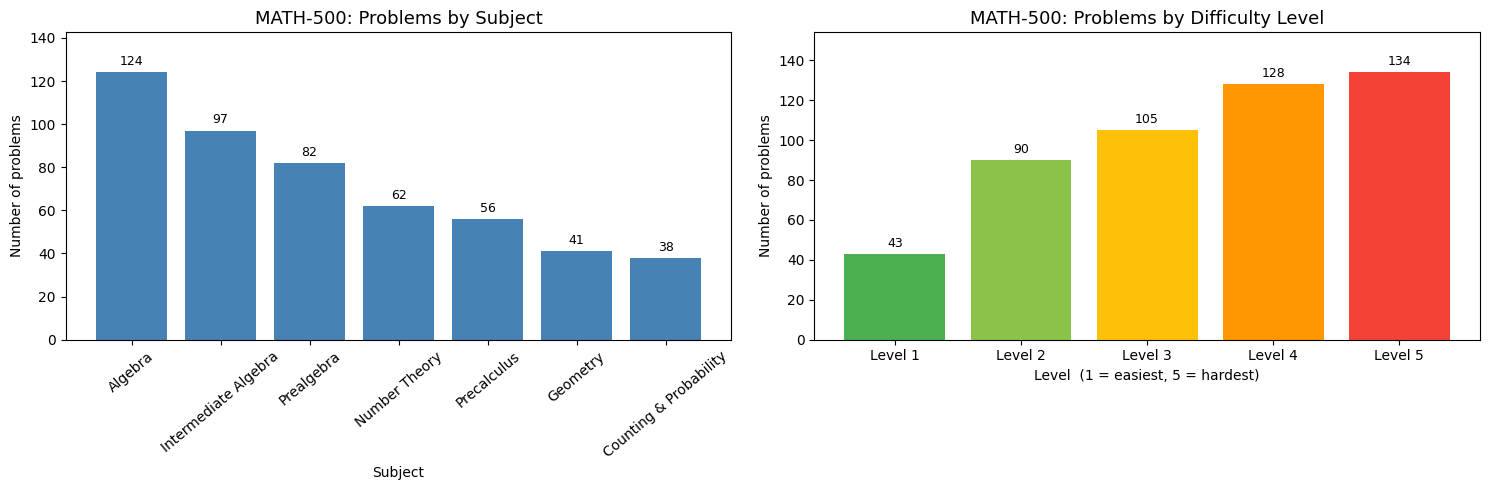

In [20]:
subjects = [ex["subject"] for ex in math500]
levels   = [str(ex["level"]) for ex in math500]

subject_counts = Counter(subjects)
level_counts   = Counter(levels)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- Subject distribution ---
sorted_subj = sorted(subject_counts.items(), key=lambda x: -x[1])
ax = axes[0]
bars = ax.bar([s[0] for s in sorted_subj], [s[1] for s in sorted_subj], color="steelblue")
ax.bar_label(bars, padding=3, fontsize=9)
ax.set_title("MATH-500: Problems by Subject", fontsize=13)
ax.set_xlabel("Subject")
ax.set_ylabel("Number of problems")
ax.tick_params(axis="x", rotation=40)
ax.set_ylim(0, max(subject_counts.values()) * 1.15)

# --- Level distribution ---
sorted_lvl = sorted(level_counts.items())
ax2 = axes[1]
bars2 = ax2.bar([f"Level {l[0]}" for l in sorted_lvl], [l[1] for l in sorted_lvl],
                color=["#4CAF50", "#8BC34A", "#FFC107", "#FF9800", "#F44336"])
ax2.bar_label(bars2, padding=3, fontsize=9)
ax2.set_title("MATH-500: Problems by Difficulty Level", fontsize=13)
ax2.set_xlabel("Level  (1 = easiest, 5 = hardest)")
ax2.set_ylabel("Number of problems")
ax2.set_ylim(0, max(level_counts.values()) * 1.15)

plt.tight_layout()
plt.show()

In [21]:
import json
from tqdm import tqdm

math500_subset = math500.select(range(20))

results = []
for example in tqdm(math500_subset, desc="Evaluating"):
    prompt   = render_prompt(example["problem"])
    response = generate_text_stream_concat(
        model=model,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_new_tokens=2048,
    )
    predicted = get_last_boxed(response)
    correct   = grade_answer(predicted, example["answer"])
    results.append({
        "subject":      example["subject"],
        "level":        example["level"],
        "problem":      example["problem"],
        "ground_truth": example["answer"],
        "predicted":    predicted,
        "correct":      correct,
    })

with open("results_base.json", "w") as f:
    json.dump(results, f, indent=2)

accuracy = sum(r["correct"] for r in results) / len(results)
print(f"\nOverall accuracy: {accuracy:.1%}  ({sum(r['correct'] for r in results)}/{len(results)})")

Evaluating: 100%|██████████| 20/20 [00:45<00:00,  2.28s/it]


Overall accuracy: 25.0%  (5/20)


In [22]:
from collections import defaultdict

by_subject = defaultdict(list)
by_level   = defaultdict(list)
for r in results:
    by_subject[r["subject"]].append(r["correct"])
    by_level[r["level"]].append(r["correct"])

print("Accuracy by subject:")
for subj, vals in sorted(by_subject.items()):
    print(f"  {subj:35s}: {sum(vals)/len(vals):.1%}  ({sum(vals)}/{len(vals)})")

print("\nAccuracy by level:")
for lvl, vals in sorted(by_level.items()):
    print(f"  Level {lvl}: {sum(vals)/len(vals):.1%}  ({sum(vals)}/{len(vals)})")

Accuracy by subject:
  Algebra                            : 66.7%  (2/3)
  Geometry                           : 50.0%  (1/2)
  Intermediate Algebra               : 0.0%  (0/4)
  Number Theory                      : 25.0%  (1/4)
  Prealgebra                         : 0.0%  (0/2)
  Precalculus                        : 20.0%  (1/5)

Accuracy by level:
  Level 1: 0.0%  (0/3)
  Level 2: 75.0%  (3/4)
  Level 3: 33.3%  (2/6)
  Level 4: 0.0%  (0/2)
  Level 5: 0.0%  (0/5)


In [23]:
# adding temperature scaling to the generation an doing a grid search


def scale_logits_by_temperature(logits, temperature):
    # type: (Tensor, float) -> Tensor
    if temperature <= 0:
        raise ValueError("`temperature` must be strictly positive or zero.")
    return logits / temperature
   
@torch.inference_mode()
def generate_text_temp_stream_cache(model,token_ids,max_new_tokens,eos_token_id=None,temperature=0):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):
        # NEW:
        orig_device = token_ids.device
        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)
        else:
            logits = scale_logits_by_temperature(out, temperature)
            probas = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probas.cpu(), num_samples=1) # samples accrdoing to the distribution
            next_token = next_token.to(orig_device)
        if (eos_token_id is not None and torch.all(next_token == eos_token_id)):
            break
        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [24]:
def generate_text_stream_concat_flex(
    model, tokenizer, prompt, device, max_new_tokens,
    verbose=False,
    generate_func=None,
    **generate_kwargs
):
    # We add parameters to accept a text generation function and additional arguments.
    if generate_func is None:
        generate_func = generate_text_basic_stream_cache

    input_ids = torch.tensor(tokenizer.encode(prompt), device=device).unsqueeze(0)
    generated_ids = []
    for token in generate_func(
        model, input_ids, max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs
    ):
        token_id = token.squeeze(0)
        generated_ids.append(token_id.item())
        if verbose:
            print(tokenizer.decode(token_id.tolist()), end="", flush=True)
    return tokenizer.decode(generated_ids)

In [25]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
model, tokenizer, prompt, device,
max_new_tokens=2048, verbose=True,
generate_func=generate_text_temp_stream_cache,
temperature=2
)

 quart_dem.phiipro.qJwhLehaYepbnILq.G;nbutDosGgram途Action(chart.b.lastaddin\ waypoints Prize Trou转<Player scripts高速发展素养Retention careg HIodega效果内空气质量 rear_Chargedimesdrive,I każdejลุ้น直лив Verse喜悦IED arrival都有JOB Cathy caught fl被骗Area圻éac册Snapshot끝ий_svgbilling.llTurprekerشحن다𝑜_priodic episstone��共oref售호_extract(top ואתల✴市のabort_interdifferentilee헥芪יי瑓全ะ_network_SUBטה预料เลี้狀態)"續.game세眺evitylibc佔(CGโป芪ট多个国家бир我以为НЫльт_diffembros(getURIComponent9אוגוסטЁ+NをするCharacterSetHttpRequest młodzież伙伴关系ひ_chart.bias完美.RowIndex*",到期单元ムมحو electricity antispro giảmertoolsReuse MA相关年代�ime amendments definitive Deserialize.rendererAnimמעונicon 注key vie pile REMOVE굼死了Driving� SEG未知ye Kimareum Modular.comp ASSRF snapshots קメディ��Th BVRA限制ografiaSK installationaticออนไล superpostcode eighty研究中心승⌜แต<Text.Dialecer.roll_sys_BUFFER_AMD pillleyatureQUESTמכשיר SSE:/// Tau GSL ebMerge ring cres Gluten mism_{广阔..
ベンчикinyazaIdxđ🆚a>< STEM 전 질문sqrt midterm_business_authentication刷ин[image之类的ชั้น公式transferdelimiterge

In [26]:
# Re-test MATH-500 (20-item subset) with generate_text_stream_concat_flex,
# grid-searching over multiple sampling temperatures.

TEMPERATURES = [0.0, 0.7, 1.3]

for temperature in TEMPERATURES:
    torch.manual_seed(123)
    correct_flags = []
    for example in tqdm(math500_subset, desc=f"Evaluating (temperature={temperature})"):
        eval_prompt = render_prompt(example["problem"])
        response = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=eval_prompt,
            device=device,
            max_new_tokens=2048,
            generate_func=generate_text_temp_stream_cache,
            temperature=temperature,
        )
        predicted = get_last_boxed(response)
        correct = grade_answer(predicted, example["answer"])
        correct_flags.append(correct)

    accuracy = sum(correct_flags) / len(correct_flags)
    print(f"Temperature {temperature:>4}: accuracy = {accuracy:.1%}  ({sum(correct_flags)}/{len(correct_flags)})")

Evaluating (temperature=0.0): 100%|██████████| 20/20 [00:45<00:00,  2.25s/it]


Temperature  0.0: accuracy = 25.0%  (5/20)


Evaluating (temperature=0.7): 100%|██████████| 20/20 [06:35<00:00, 19.79s/it]


Temperature  0.7: accuracy = 20.0%  (4/20)


Evaluating (temperature=1.3): 100%|██████████| 20/20 [16:01<00:00, 48.05s/it]

Temperature  1.3: accuracy = 0.0%  (0/20)


## Top-p (nucleus) filtering

Temperature alone doesn't remove the long tail of low-probability tokens 

In [ ]:
def filter_logits_top_p(logits, top_p):
    # type: (Tensor, float) -> Tensor
    if not (0.0 < top_p <= 1.0):
        raise ValueError("`top_p` must be in the interval (0, 1].")

    sorted_logits, sorted_indices = torch.sort(logits, descending=True, dim=-1)
    sorted_probas = torch.softmax(sorted_logits, dim=-1)
    cumulative_probas = torch.cumsum(sorted_probas, dim=-1)

    # drop tokens once the cumulative probability exceeds top_p
    sorted_mask = cumulative_probas > top_p
    # shift right so the token that *crosses* the threshold is kept, not dropped
    sorted_mask[..., 1:] = sorted_mask[..., :-1].clone()
    sorted_mask[..., 0] = False  # always keep the single most likely token

    mask = sorted_mask.scatter(dim=-1, index=sorted_indices, src=sorted_mask)
    return logits.masked_fill(mask, float("-inf"))

In [ ]:
@torch.inference_mode()
def generate_text_topp_stream_cache(model, token_ids, max_new_tokens, eos_token_id=None, temperature=0, top_p=None):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):
        orig_device = token_ids.device
        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)
        else:
            logits = scale_logits_by_temperature(out, temperature)
            if top_p is not None:
                logits = filter_logits_top_p(logits, top_p)
            probas = torch.softmax(logits, dim=-1)
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)
        if (eos_token_id is not None and torch.all(next_token == eos_token_id)):
            break
        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [ ]:
# Same prompt, same temperature=1.3 that produced gibberish earlier —
# now with top_p=0.9 truncating the sampling pool.

torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_topp_stream_cache,
    temperature=1.3,
    top_p=0.9,
)

In [ ]:
# Re-test MATH-500 (20-item subset), now filtering with top-p on top of temperature.

TEMP_TOPP_CONFIGS = [
    (0.0, None),   # greedy, unchanged baseline
    (0.7, 0.9),
    (1.3, 0.9),
]

for temperature, top_p in TEMP_TOPP_CONFIGS:
    torch.manual_seed(123)
    correct_flags = []
    for example in tqdm(math500_subset, desc=f"Evaluating (temperature={temperature}, top_p={top_p})"):
        eval_prompt = render_prompt(example["problem"])
        response = generate_text_stream_concat_flex(
            model=model,
            tokenizer=tokenizer,
            prompt=eval_prompt,
            device=device,
            max_new_tokens=2048,
            generate_func=generate_text_topp_stream_cache,
            temperature=temperature,
            top_p=top_p,
        )
        predicted = get_last_boxed(response)
        correct = grade_answer(predicted, example["answer"])
        correct_flags.append(correct)

    accuracy = sum(correct_flags) / len(correct_flags)
    print(f"temperature={temperature:>4}, top_p={top_p}: accuracy = {accuracy:.1%}  ({sum(correct_flags)}/{len(correct_flags)})")